### Environment Initialization & Determinism
Configuring the GPU backend and setting global random seeds to ensure all training results and dataset splits are 100% reproducible.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

physical_gpus = tf.config.list_physical_devices('GPU')
if physical_gpus:
  try:
    for gpu in physical_gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
      print(f" Successfully Found GPU: {physical_gpus}")
  except RuntimeError as error:
        print(f" [ERROR] Could not configure GPU: {error}")
else:
    print(" [WARNING] No GPU detected. Running on CPU.")

 Successfully Found GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Dataset Fetching and filtering
Streaming the Labeled Faces in the Wild (LFW) dataset directly into the Colab environment via the Kaggle API to bypass local hardware storage limits.
Filtering the raw dataset to exclude individuals with insufficient data. Only classes with a minimum of 40 images are retained to ensure the model has enough samples to extract meaningful facial features.

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub
import shutil
from pathlib import Path

print("Downlaoding raw dataset from kaggle\n")
cache_dir = kagglehub.dataset_download("jessicali9530/lfw-dataset")
if cache_dir:
  print(f"Downloaded succesfully: {cache_dir}")

cache_dir = Path(cache_dir)
source_faces_dir = list(cache_dir.rglob("lfw-deepfunneled"))[-1] #revursive glob, specifically secah folder from -1
filtered_face_dir = Path("/content/lfw-deepfunneled")

if filtered_face_dir.exists():
  shutil.rmtree(filtered_face_dir)

filtered_face_dir.mkdir(parents=True, exist_ok=True)

MIN_IMAGES = 40
selected_classes = 0
total_images_saved = 0

print(f"Filtering dataset for individuals with >= {MIN_IMAGES}")
for person_dir in source_faces_dir.iterdir():
  if person_dir.is_dir():
    images = list(person_dir.glob("*.jpg")) #specifficaly search for jpg files in every dir

    if len(images) >= MIN_IMAGES:
      dest_dir = filtered_face_dir / person_dir.name #connects the dire with person name (i-e dire name)
      shutil.copytree(person_dir, dest_dir) # copy the whole person dir and paste into /content/lfw-deepfunneled
      selected_classes += 1
      total_images_saved += len(images)
      print(f"Kept: {person_dir.name:<20} | Images: {len(images)}")

print(f"\n [SUCCESS] Data Curation Complete!")
print(f" Total Recognizable People (Classes): {selected_classes}")
print(f" Total Usable Images: {total_images_saved}")
print(f" Filtered Dataset Path: {filtered_face_dir}")


Downlaoding raw dataset from kaggle



100%|██████████| 112M/112M [00:01<00:00, 100MB/s] 

Extracting files...


Downloaded succesfully: /root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4
Filtering dataset for individuals with >= 40
Kept: Jean_Chretien        | Images: 55
Kept: Lleyton_Hewitt       | Images: 41
Kept: Jacques_Chirac       | Images: 52
Kept: Ariel_Sharon         | Images: 77
Kept: Laura_Bush           | Images: 41
Kept: Gerhard_Schroeder    | Images: 109
Kept: Colin_Powell         | Images: 236
Kept: Vladimir_Putin       | Images: 49
Kept: George_W_Bush        | Images: 530
Kept: Gloria_Macapagal_Arroyo | Images: 44
Kept: Junichiro_Koizumi    | Images: 60
Kept: Luiz_Inacio_Lula_da_Silva | Images: 48
Kept: Jennifer_Capriati    | Images: 42
Kept: John_Ashcroft        | Images: 53
Kept: Tony_Blair           | Images: 144
Kept: Donald_Rumsfeld      | Images: 121
Kept: Arnold_Schwarzenegger | Images: 42
Kept: Hugo_Chavez          | Images: 71
Kept: Serena_Williams      | Images: 52

 [SUCCESS] Data Curation Complete!
 Total Recognizable People (Classes): 19
 Total Usab

## Train/Test split and Autotunning
splitting the data into 80/20 training and testing from root directory and extracting the folders names along with autotuning the faster the every epoch set

In [4]:
BATCH_SIZE = 42
IMAGES_SIZE = (224, 224)

#function scans a directory and turns it into a highly efficient data stream.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=filtered_face_dir, #our directory /content/lfw-deepfunneled
    validation_split=0.2, #20/80
    subset="training", #initializing the train_dataset
    seed=SEED, #ensures that the 80/20 random split is exactly the same every time
    image_size=IMAGES_SIZE,
    batch_size=BATCH_SIZE)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=filtered_face_dir,
    validation_split=0.2,
    subset="validation", #initializng the val_dataset
    seed=SEED,
    image_size=IMAGES_SIZE,
    batch_size=BATCH_SIZE)

class_names = train_dataset.class_names #extract folder name as strings to the corelated images of folder
print(f"\n [SUCCESS] Automatically mapped {len(class_names)} classes: {class_names[:5]}...")

AUTOTUNE = tf.data.AUTOTUNE #dynamically figure out how much CPU power to use
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) #Saves the resized images in a temporary memory buffer after the first epoch, making 2 epoch work 50% faster
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 1867 files belonging to 19 classes.
Using 1494 files for training.
Found 1867 files belonging to 19 classes.
Using 373 files for validation.

 [SUCCESS] Automatically mapped 19 classes: ['Ariel_Sharon', 'Arnold_Schwarzenegger', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W_Bush']...


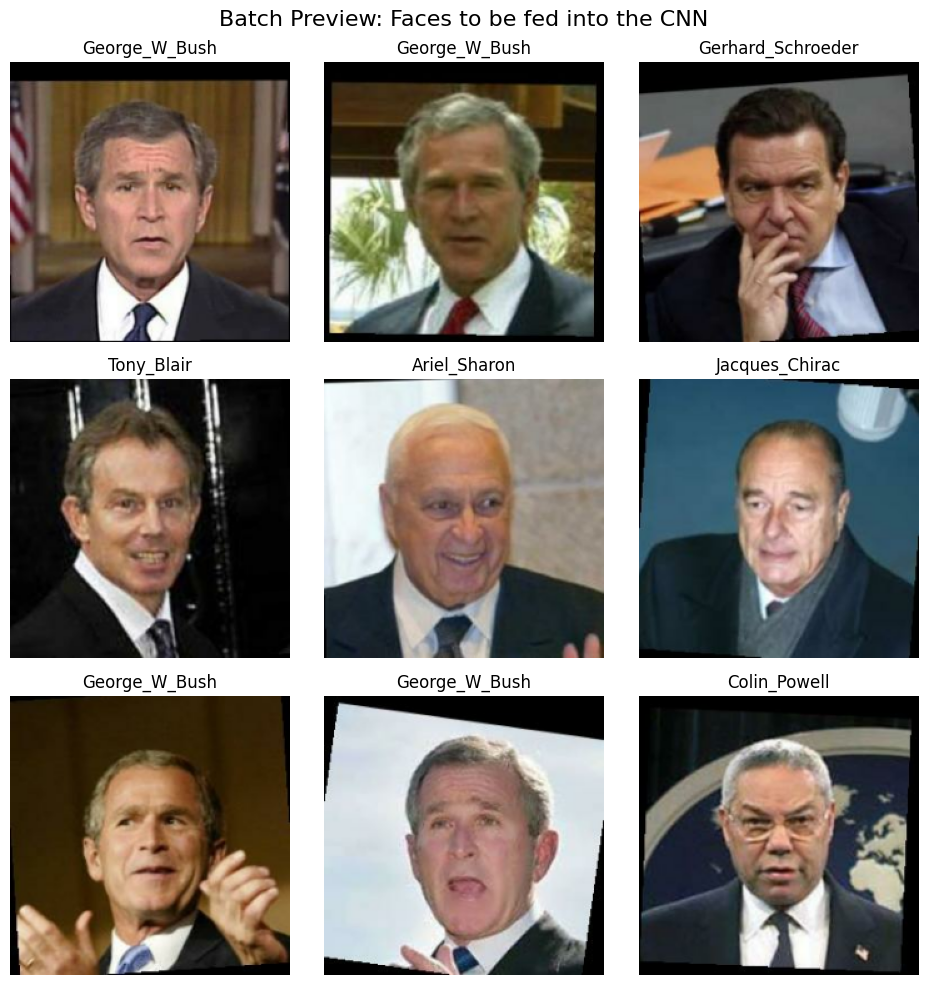

In [5]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
    plt.tight_layout()
plt.suptitle("Batch Preview: Faces to be fed into the CNN", fontsize=16)
plt.tight_layout()
plt.show()

##Data Augmentation.
Dataset of 1800+ images is very short in the term of deep learning and which can cause our model to memorize all of data and will fail on new one **overfitting**. to prevent this I'm creating a mini-pipeline that randomly flips the images horizontally and slightly rotates them every time they pass into the model. and for the model, a flipped face looks like a brand new piece of data, effectively multiplying our dataset size

In [6]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.1, seed=SEED),
        tf.keras.layers.RandomZoom(0.1, seed=SEED)
    ], name="data_augmentation_pipeline")

print("initializing Data Augmentation Pipeline.")

initializing Data Augmentation Pipeline.


## BASELINE MODEL - CNN
Constructing a lightweight, custom Convolutional Neural Network (CNN) from scratch which will serve as baseline to validate the data pipeline and establish a minimum accuracy threshold before introducing complex pre-trained models

In [7]:
num_classes = len(class_names)
print("Building a custom Convolutional Neural Network BaseLine ")
baseline_model = tf.keras.Sequential([
    data_augmentation, #using our augmentation function to prevent OVERFTTING
    tf.keras.layers.Rescaling(1./255), #normalizing the pixel from 1 to 255, for faster execution and accuracy

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)), #first layer extracting 32 features

    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)), #second layer extracting 64 features

    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)), #third layer extracting 128 features from a single picture

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5, seed=SEED), #randomly turns off 50% of the neurons to prevent relying too heavily on one specific pixel (OVERFITTING)

    tf.keras.layers.Dense(units=num_classes, activation='softmax')
], name="Baseline_Custom_CNN")

baseline_model.compile(
    optimizer='adam', #algorithm that physically updates the model's math weight
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])

baseline_model.build(input_shape=(None, 224, 224, 3))
print("\n [SUCCESS] Baseline Model Compiled!")
baseline_model.summary()

Building a custom Convolutional Neural Network BaseLine 

 [SUCCESS] Baseline Model Compiled!


Model: "Baseline_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_pipeline      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,883 (49.37 MB)

 Trainable params: 12,940,883 (49.37 MB)

 Non-trainable params: 0 (0.00 B)

## Baseline Model Training & Callback Integration
Executing the baseline training loop. Implemented ModelCheckpoint to save the optimal weights and EarlyStopping to stop the training automatically if validation loss degrades.

In [8]:
checkpoint_path = "/content/baseline_best.keras"
callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True, #saves the output of best epochs only
    monitor="val_accuracy", #decision based on accuracies
    mode="max",
    verbose=1), #prints the epoch message

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", #validation loss to overcome OVERFITTING
        patience=5, #not imrovement after 5 epochs then break
        restore_best_weights=True, #brinsg back that epoch which has better results
        verbose=1)
    ]

print("Starting Model Training.")
EPOCHS = 20
history = baseline_model.fit(
    train_dataset,
    validation_data= val_dataset,
    epochs=EPOCHS,
    callbacks= callbacks_list
)

Starting Model Training.
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2355 - loss: 2.7228
Epoch 1: val_accuracy improved from None to 0.25737, saving model to /content/baseline_best.keras

Epoch 1: finished saving model to /content/baseline_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.2637 - loss: 2.6544 - val_accuracy: 0.2574 - val_loss: 2.6125
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2797 - loss: 2.5919
Epoch 2: val_accuracy improved from 0.25737 to 0.29491, saving model to /content/baseline_best.keras

Epoch 2: finished saving model to /content/baseline_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.2959 - loss: 2.5268 - val_accuracy: 0.2949 - val_loss: 2.3907
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3349 - loss: 2.3390
Epoch 3: val_accuracy improved from 0.29491 to 0.29759, saving model to /content/baseline_best.keras

Epoch 3: finished saving model to /content/baseline_best.

 ## Transfer Learning to MobileNetV2
  using google's module MobileNetV2 which has 1.4 million images records training, in order to increase accuracy as it alreayd knows many features of human face , as our 1400 images data is too small to Deep learning models.


In [9]:
IMG_SHAPE = (224, 224, 3) #input shape for MobileNet2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False, #only includling models body (extracting its trained features)
    weights='imagenet'
)

base_model.trainable = False

#Transfer Learning architecture

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs) #Apply data augmentation
x = tf.keras.applications.mobilenet_v2.preprocess_input(x) #MobileNetV2 uses Mean Standardization [-1.0, 1.0]
x = base_model(x, training=False) # Pass through the frozen feature extraction base
x = tf.keras.layers.GlobalAveragePooling2D()(x) #2D spatial features into a 1D vector
x = tf.keras.layers.Dense(128, activation='relu')(x) #Dense reasoning layer with Dropout
x = tf.keras.layers.Dropout(0.3, seed=SEED)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x) #classification layer with our 19 people
mobilenet_model = tf.keras.Model(inputs, outputs, name="TransferLearning_MobileNetV2") #completw Keras functional model

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("\n [SUCCESS] MobileNetV2 Transfer Learning Model Built & Compiled!")
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 [SUCCESS] MobileNetV2 Transfer Learning Model Built & Compiled!


Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_pipeline      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,403 (9.25 MB)

 Trainable params: 166,419 (650.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
checkpoint_path_tl = "/content/mobilenet_feature_extractor.keras"

callbacks_tl = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path_tl,
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
        verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1)
]

print("Feature Extraction Training...")
INITIAL_EPOCHS = 15

history_tl = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_tl)

print("\n [SUCCESS] Feature Extraction Training Complete!")

Feature Extraction Training...
Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1958 - loss: 2.9676
Epoch 1: val_accuracy improved from None to 0.28954, saving model to /content/mobilenet_feature_extractor.keras

Epoch 1: finished saving model to /content/mobilenet_feature_extractor.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.2677 - loss: 2.6059 - val_accuracy: 0.2895 - val_loss: 2.2472
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3436 - loss: 2.2584
Epoch 2: val_accuracy improved from 0.28954 to 0.36997, saving model to /content/mobilenet_feature_extractor.keras

Epoch 2: finished saving model to /content/mobilenet_feature_extractor.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.3695 - loss: 2.1685 - val_accuracy: 0.3700 - val_loss: 1.9813
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4601 - loss: 1.8477
Epoch 3: val_accuracy improved from 0.36997 to 0.46649, saving model to /content/mobilenet_featur

## Fine-Tuning
unfreezing the last 30 layers of the MobileNetV2 model then continue training with a very small learning rate ($10^{5}$). This lets the model carefully learn subtle facial details without erasing the general shapes and patterns it already knows.

In [11]:
base_model.trainable = True #MobileNtV2 model

total_layers = len(base_model.layers)
print(f" Total layers in MobileNetV2 base: {total_layers}")

FINE_TUNE_AT = total_layers - 30  #unfreezing only the top ~30 layers which are generic features
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False #disbaling those layers

print(f" Frozen layers: {FINE_TUNE_AT}")
print(f" Trainable layers (fine-tuning): {total_layers - FINE_TUNE_AT}")

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

checkpoint_path_ft = "/content/mobilenet_fine_tuned_best.keras"
callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path_ft,
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

FINE_TUNE_EPOCHS = 15
TOTAL_EPOCHS = len(history_tl.epoch) + FINE_TUNE_EPOCHS

print(f"\n Starting Fine-Tuning from epoch {len(history_tl.epoch)} to {TOTAL_EPOCHS}...")

history_fine = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=TOTAL_EPOCHS,
    initial_epoch=len(history_tl.epoch),
    callbacks=callbacks_ft
)

print("\n [SUCCESS] Fine-Tuning Stage Complete!")

 Total layers in MobileNetV2 base: 154
 Frozen layers: 124
 Trainable layers (fine-tuning): 30

 Starting Fine-Tuning from epoch 15 to 30...
Epoch 16/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4527 - loss: 1.8115
Epoch 16: val_accuracy improved from None to 0.71314, saving model to /content/mobilenet_fine_tuned_best.keras

Epoch 16: finished saving model to /content/mobilenet_fine_tuned_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.4819 - loss: 1.7208 - val_accuracy: 0.7131 - val_loss: 0.8974
Epoch 17/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5587 - loss: 1.5024
Epoch 17: val_accuracy improved from 0.71314 to 0.73458, saving model to /content/mobilenet_fine_tuned_best.keras

Epoch 17: finished saving model to /content/mobilenet_fine_tuned_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.5710 - loss: 1.4590 - val_accuracy: 0.7346 - val_loss: 0.8783
Epoch 18/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6160 - 

## Visualizing the Learning Curves
Plotting the training and validation metrics across both the Feature Extraction and Fine-Tuning phases to visually verify model convergence and check for overfitting.

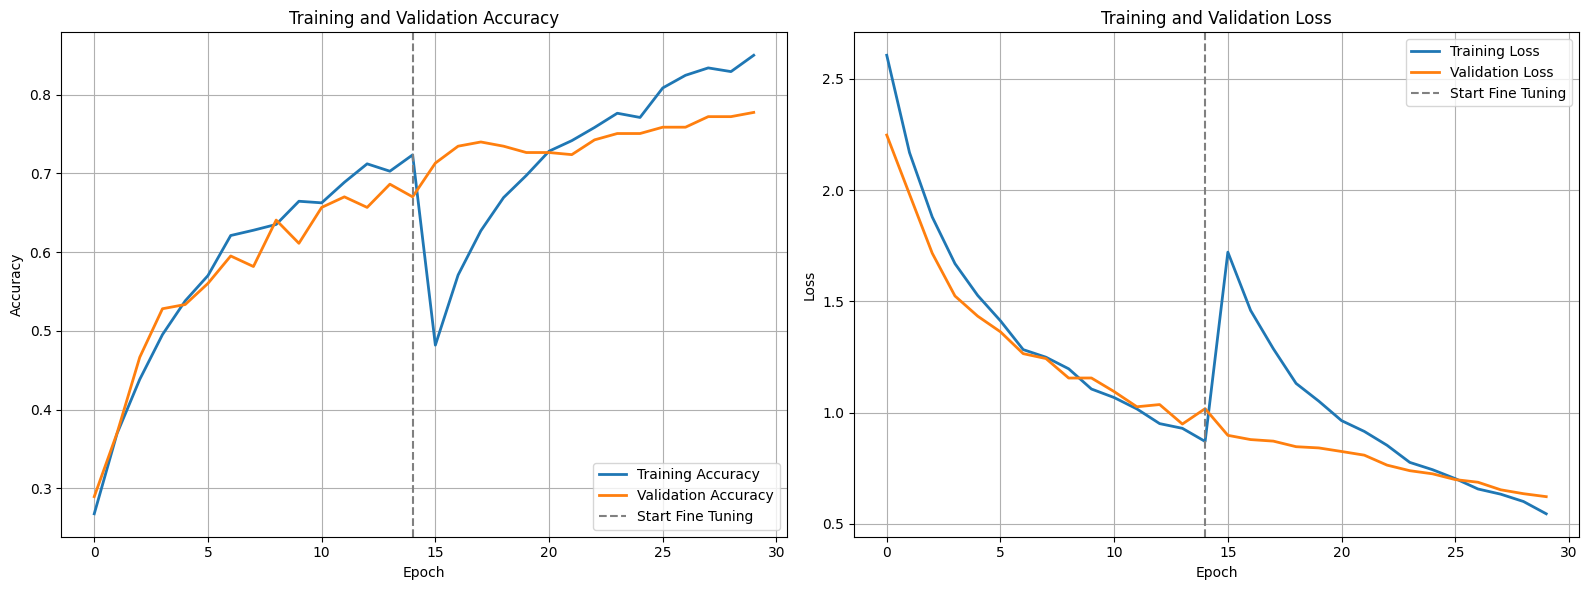

In [12]:
#(Feature Extraction)
acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']

#(Fine-Tuning) to the end of the lists
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(16, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', linewidth=2)
plt.axvline(x=INITIAL_EPOCHS-1, color='gray', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=INITIAL_EPOCHS-1, color='gray', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

##Statistical Evaluation & Confusion Matrix
Running bulk predictions on the unseen testing data to generate a detailed classification report (Precision, Recall, F1-Score) and a Seaborn heatmap matrix to identify specific class-level misclassifications.

 Generating predictions on the unseen testing data. Please wait...

Predictions Generated!

(Classification Report)
                           precision    recall  f1-score   support

             Ariel_Sharon       0.85      0.92      0.88        12
    Arnold_Schwarzenegger       0.50      0.17      0.25         6
             Colin_Powell       0.97      0.71      0.82        45
          Donald_Rumsfeld       0.62      0.88      0.72        24
            George_W_Bush       0.83      0.95      0.89        96
        Gerhard_Schroeder       0.69      0.46      0.55        24
  Gloria_Macapagal_Arroyo       0.92      0.92      0.92        13
              Hugo_Chavez       0.73      0.73      0.73        11
           Jacques_Chirac       1.00      0.55      0.71        11
            Jean_Chretien       1.00      0.44      0.62         9
        Jennifer_Capriati       0.86      0.75      0.80         8
            John_Ashcroft       1.00      0.33      0.50        15
        Juni

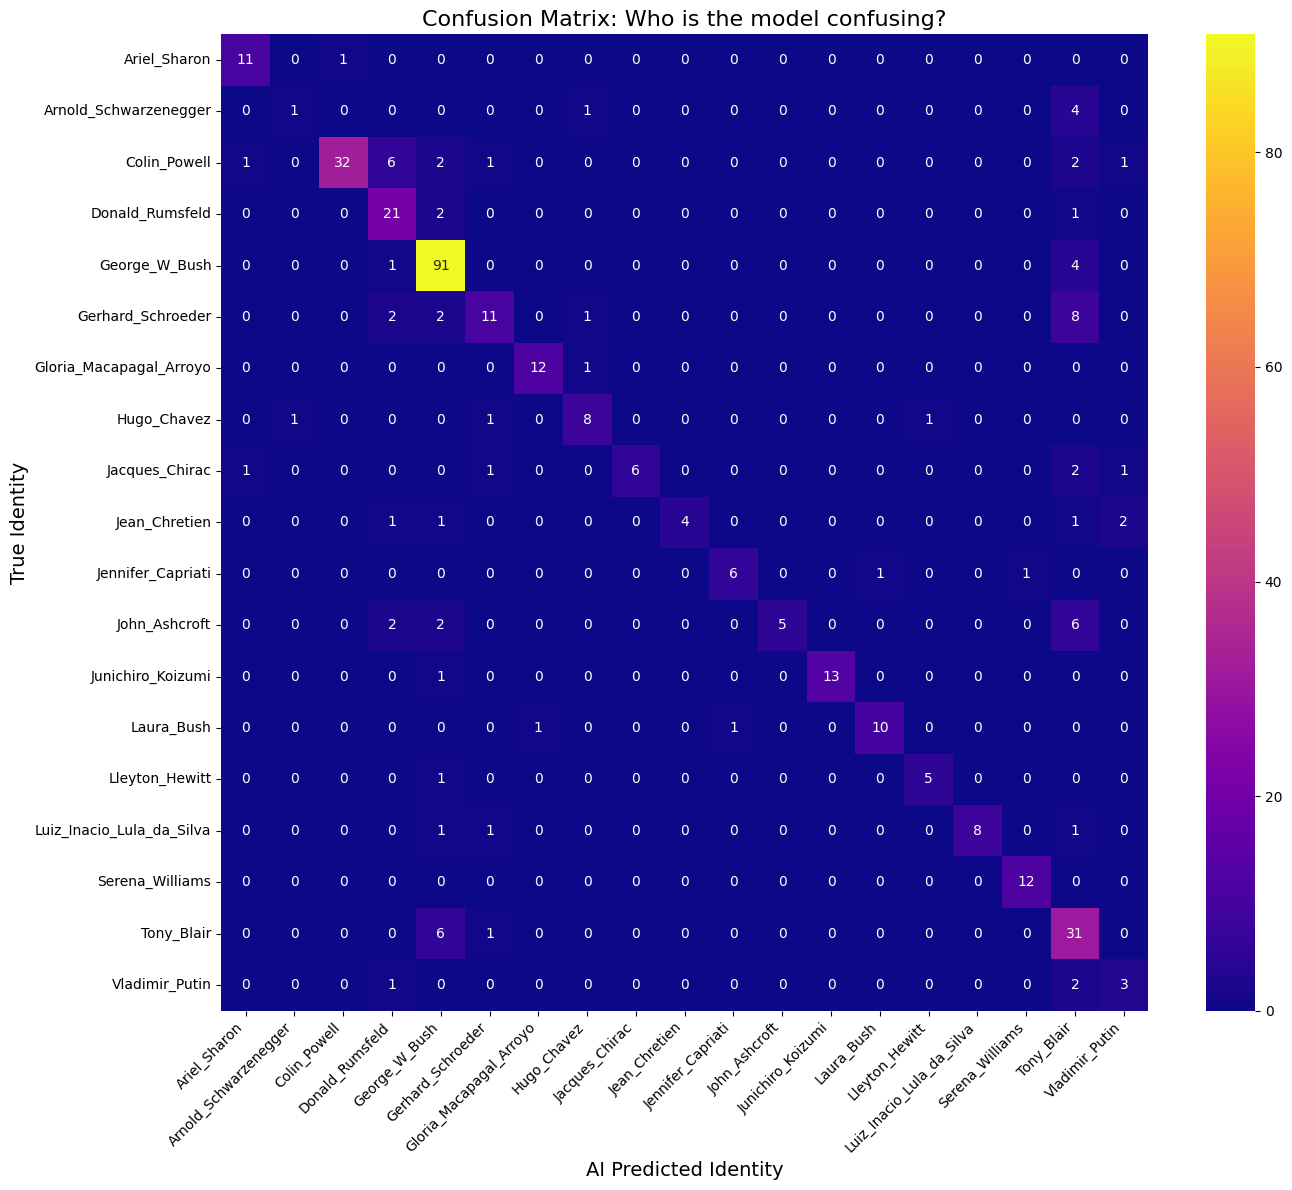

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print(" Generating predictions on the unseen testing data. Please wait...")
y_true = []
y_pred = []
for images, labels in val_dataset:
    batch_predictions = mobilenet_model.predict(images, verbose=0) #raw probability scores from the fine-tuned model
    predicted_classes = np.argmax(batch_predictions, axis=1) #extracting highest prob from pridiction

    y_pred.extend(predicted_classes)
    y_true.extend(labels.numpy())

print("\nPredictions Generated!")
print("\n(Classification Report)")
print(classification_report(y_true, y_pred, target_names=class_names))
Confusion_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(Confusion_matrix, annot=True, fmt='d', cmap='plasma',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Who is the model confusing?', fontsize=16)
plt.xlabel('AI Predicted Identity', fontsize=14)
plt.ylabel('True Identity', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Real Time Inference & Interpretability

Simulating production deployment. This script accepts a raw image file path, applies the required MobileNetV2 mathematical preprocessing, and outputs a single class prediction with a confidence percentage.

Initializing Inference Pipeline


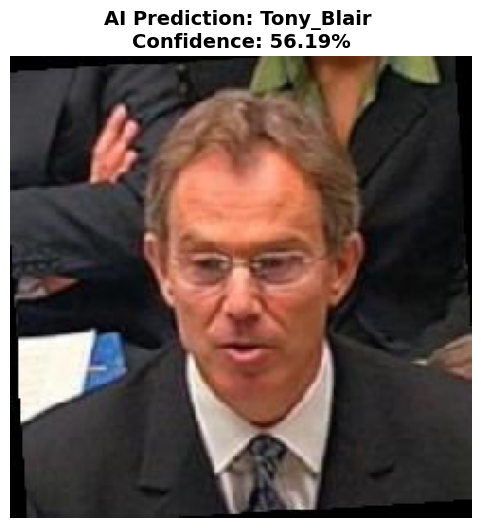

In [22]:
from tensorflow.keras.preprocessing import image

print("Initializing Inference Pipeline")
all_image_paths = list(filtered_face_dir.rglob("*.jpg"))
random_image_path = str(random.choice(all_image_paths)) #randomly select one file

def predict_single_image(model, image_path, class_labels):
  raw_image = image.load_img(image_path, target_size=IMAGES_SIZE)
  image_array = image.img_to_array(raw_image)
  image_batch = np.expand_dims(image_array, axis=0) #tf work on 4D so...!
  processed_image = tf.keras.applications.mobilenet_v2.preprocess_input(image_batch)
  predictions = model.predict(processed_image, verbose=0)

  predicted_index = np.argmax(predictions[0])
  predicted_name = class_labels[predicted_index]
  confidence = predictions[0][predicted_index] * 100

  plt.figure(figsize=(6, 6))
  plt.imshow(raw_image)
  plt.title(f"AI Prediction: {predicted_name} \nConfidence: {confidence:.2f}%", fontsize=14, fontweight='bold')
  plt.axis("off")
  plt.show()

  return processed_image, predicted_name

processed_tensor, prediction = predict_single_image(mobilenet_model, random_image_path, class_names)

## Interpretability (Grad-CAM Forensic Analysis)
Implementing Gradient-weighted Class Activation Mapping (Grad-CAM). This extracts the spatial gradients from the final convolutional layer to generate a thermal heatmap, visually explaining exactly which facial pixels triggered the model's final decision.

Grad-CAM Forensic Explainer


/tmp/ipykernel_2424/344019971.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


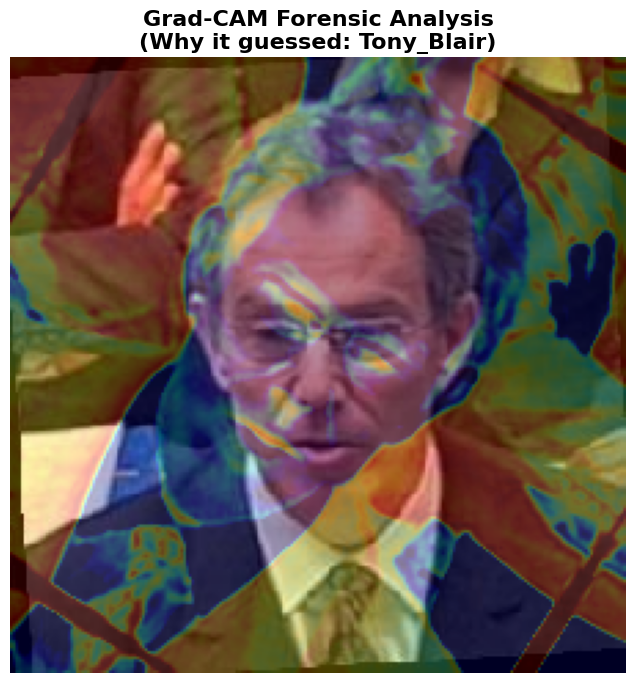


 [SUCCESS] Phase 5 Complete! Your Image Recognition System is fully operational.


In [23]:
import matplotlib.cm as cm

print("Grad-CAM Forensic Explainer")

def make_gradcam_heatmap(img_array, full_model):
    base_model_layer = next(l for l in full_model.layers if isinstance(l, tf.keras.Model)) #searches our main pipeline to find the exact layers MobileNetV2 base
    head_input = tf.keras.Input(shape=base_model_layer.output_shape[1:])
    x = head_input
    start_idx = full_model.layers.index(base_model_layer) + 1
    for layer in full_model.layers[start_idx:]:
        x = layer(x)
    head_model = tf.keras.Model(head_input, x)

    with tf.GradientTape() as tape: #saves the mathameticsl records forcefully in tensorflow.
        last_conv_output = base_model_layer(img_array)
        tape.watch(last_conv_output)
        preds = head_model(last_conv_output)

        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    grads = tape.gradient(top_class_channel, last_conv_output) #calculates the partial derivatives 7x7
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_output = last_conv_output.numpy()[0]
    pooled_grads = pooled_grads.numpy()
    for i in range(pooled_grads.shape[-1]):
        last_conv_output[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(last_conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap) # Normalize values between 0.0 and 1.0

    return heatmap


heatmap = make_gradcam_heatmap(processed_tensor, mobilenet_model)
raw_img = tf.keras.preprocessing.image.load_img(random_image_path, target_size=IMAGES_SIZE)
raw_img_array = tf.keras.preprocessing.image.img_to_array(raw_img)
heatmap_colored = np.uint8(255 * heatmap)
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3] # Strip out the alpha channel
heatmap_colored = jet_colors[heatmap_colored]

heatmap_resized = tf.keras.preprocessing.image.array_to_img(heatmap_colored)
heatmap_resized = heatmap_resized.resize((224, 224))
heatmap_resized = tf.keras.preprocessing.image.img_to_array(heatmap_resized)

superimposed_img = heatmap_resized * 0.4 + raw_img_array
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM Forensic Analysis\n(Why it guessed: {prediction})", fontsize=16, fontweight='bold')
plt.axis("off")
plt.show()

print("\n [SUCCESS] Phase 5 Complete! Your Image Recognition System is fully operational.")